# MLOps: Operationalization

You have reached the final lesson of Time Series Analysis & Forecasting. We have conquered Stationarity, engineered Lags, built LSTMs and Transformers, reconciled Hierarchies, and built automated triggers to survive Concept Drift.

But there is one final hurdle. A mathematically perfect, continuously backtested Transformer model running on a cloud server is completely useless if the Supply Chain Manager does not know how to read its outputs.

**Operationalization** is the final mile of MLOps. It is the architectural discipline of translating raw mathematical tensors into business value through APIs, Dashboards, and Automated Alerting.

Operationalization bridges the gap between the Data Scientist's Python environment and the Stakeholder's daily workflow. We must define how the forecast is served, how uncertainty is communicated, and how the business interacts with the AI.

Let's set up our Python environment to simulate building a business-facing Forecasting API and Dashboard.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime, timedelta

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ MLOps Operationalization & Dashboard Environment Ready.")

✅ MLOps Operationalization & Dashboard Environment Ready.


# 1. Architecture: Batch vs. Real-Time Serving

Before you deploy a forecasting model, you must ask the business a critical question: *"When do you actually need this number?"* There are two primary ways to architect a forecasting system:

### 1. Batch Processing (The Enterprise Standard)

Most business decisions (Supply Chain ordering, Labor scheduling, Financial budgeting) happen once a day, week, or month.

* **The Architecture**: At 2:00 AM every night, an automated pipeline wakes up, queries the database for yesterday's actuals, runs the model, generates the next 30 days of forecasts, and writes the results directly into a Data Warehouse (like Snowflake or BigQuery).
* **The Interface**: When the executives open their Tableau or PowerBI dashboards at 8:00 AM, the data is already there, pre-calculated and waiting for them.

### 2. Real-Time API Serving

Used strictly for immediate, sub-second decisions (Algorithmic Trading, Dynamic Uber Pricing, Fraud Detection).

* **The Architecture**: The model is wrapped in a high-speed REST API (using frameworks like `FastAPI` or `Flask`).
* **The Interface**: The frontend application sends a JSON payload containing the current lag features, and the API instantly returns the forecast.

# 2. The Data Contract (Returning Uncertainty)

If you expose your forecast via an API, you cannot simply return a single number. You must honor the principles of **Uncertainty Quantification** (Lesson 19) and **Hierarchical Reconciliation** (Lesson 18).

The API must return a structured Data Contract containing the Point Forecast, the Boundaries, and the Metadata.

In [2]:
# 1. Simulating a FastAPI endpoint response payload
def simulate_api_response(item_id, current_lags):
    """Simulates a highly structured JSON response from a Production Forecast API."""
    
    # In reality, this calls model.predict(current_lags)
    base_forecast = 1250.0 
    
    # We construct the JSON payload
    response = {
        "metadata": {
            "model_version": "v2.1.0_Transformer",
            "timestamp": datetime.utcnow().isoformat(),
            "item_id": item_id,
            "horizon": "t+1"
        },
        "forecast": {
            "point_estimate_p50": base_forecast,
            "lower_bound_p10": base_forecast * 0.85, # 1062.5
            "upper_bound_p90": base_forecast * 1.30  # 1625.0
        },
        "alerts": {
            "is_anomaly_expected": base_forecast > 1500.0, # Simple threshold logic
            "data_drift_detected": False
        }
    }
    return json.dumps(response, indent=4)

print("--- 🚨 Production API JSON Data Contract 🚨 ---")
print(simulate_api_response(item_id="SKU_9942", current_lags=[1200, 1150, 1300]))

--- 🚨 Production API JSON Data Contract 🚨 ---
{
    "metadata": {
        "model_version": "v2.1.0_Transformer",
        "timestamp": "2026-05-19T12:34:58.138823",
        "item_id": "SKU_9942",
        "horizon": "t+1"
    },
    "forecast": {
        "point_estimate_p50": 1250.0,
        "lower_bound_p10": 1062.5,
        "upper_bound_p90": 1625.0
    },
    "alerts": {
        "is_anomaly_expected": false,
        "data_drift_detected": false
    }
}


# 3. Automated Alerting (Push vs. Pull)

Dashboards are "Pull" systems. They require a human to log in, look at the graph, and notice a problem. In a modern MLOps system, we also build "Push" systems: **Automated Alerting**.

We write scripts that parse the output of our API or Batch job. If the forecast breaches a mathematical threshold, the system physically pages a human.

* **Capacity Alert**: "The P90 Upper Bound forecast for Server #4 CPU utilization tomorrow is $98\%$. Scaling up infrastructure is recommended."
* **Anomaly Alert**: "Yesterday's Actual Sales fell below the P10 Lower Bound forecast. The pipeline has flagged an unexplained revenue drop."

# 4. Building the Executive Dashboard

Let's simulate the final deliverable. We will take a 30-day forecasted horizon, complete with uncertainty bounds and an automated threshold warning, and render it exactly how a business stakeholder would see it on a BI dashboard.

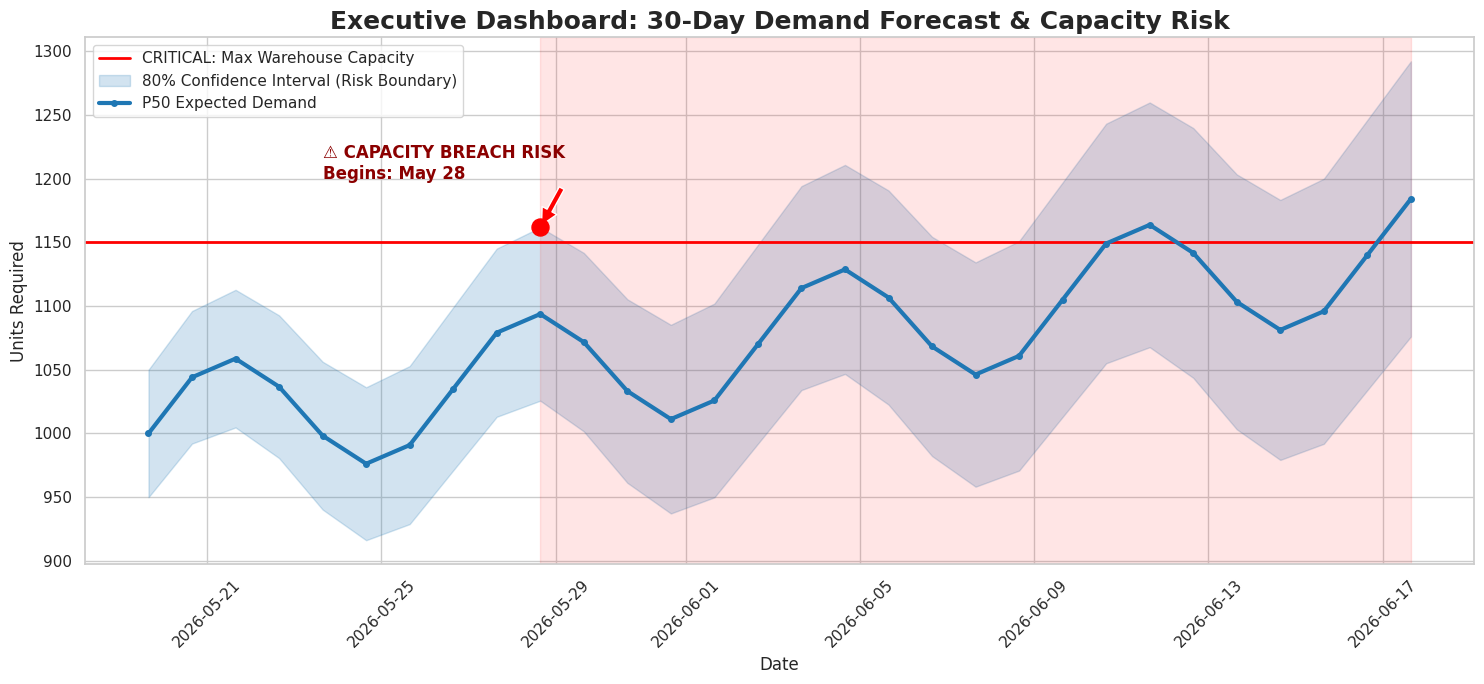


--- 📱 AUTOMATED SLACK / EMAIL ALERT GENERATED ---
⚠️ WARNING: The upper-bound demand forecast (P90) is projected to exceed the Maximum Warehouse Capacity of 1150 units starting on May 28.
➡️ Action Required: Please authorize overflow storage routing or adjust promotional spend to suppress demand.


In [3]:
# 1. Simulate a 30-Day Forecast generated by the Batch Pipeline
np.random.seed(42)
dates = pd.date_range(start=datetime.today(), periods=30)
t = np.arange(30)

# Simulate the P50 (Median) Forecast
p50_forecast = 1000 + (t * 5) + np.sin(t * (2 * np.pi / 7)) * 50

# Simulate the widening Uncertainty Bounds (P10 and P90)
uncertainty_cone = 50 + (t * 2) # Uncertainty grows as time goes on
p10_lower = p50_forecast - uncertainty_cone
p90_upper = p50_forecast + uncertainty_cone

# Define a strict Business Capacity Limit (e.g., Warehouse Space)
warehouse_capacity = 1150

# 2. Matplotlib Visualization (The Executive View)
plt.figure(figsize=(15, 7))

# Plot the Capacity Limit
plt.axhline(y=warehouse_capacity, color='red', linestyle='-', linewidth=2, label='CRITICAL: Max Warehouse Capacity')

# Plot the Uncertainty Cone
plt.fill_between(dates, p10_lower, p90_upper, color='#1f77b4', alpha=0.2, label='80% Confidence Interval (Risk Boundary)')

# Plot the Point Forecast
plt.plot(dates, p50_forecast, color='#1f77b4', linewidth=3, marker='o', markersize=4, label='P50 Expected Demand')

# 3. Dynamic Visual Alerting
# Find where the P90 bound breaches the capacity limit!
breach_idx = np.where(p90_upper > warehouse_capacity)[0][0]
breach_date = dates[breach_idx]

# Highlight the danger zone
plt.axvspan(breach_date, dates[-1], color='red', alpha=0.1)
plt.scatter(breach_date, p90_upper[breach_idx], color='red', s=150, zorder=5)
plt.annotate(f'⚠️ CAPACITY BREACH RISK\nBegins: {breach_date.strftime("%b %d")}', 
             xy=(breach_date, p90_upper[breach_idx]), 
             xytext=(breach_date - timedelta(days=5), warehouse_capacity + 50),
             arrowprops=dict(facecolor='red', shrink=0.05),
             fontsize=12, fontweight='bold', color='darkred')

plt.title("Executive Dashboard: 30-Day Demand Forecast & Capacity Risk", fontsize=18, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Units Required", fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Text-Based Alert Generation
print("\n--- 📱 AUTOMATED SLACK / EMAIL ALERT GENERATED ---")
print(f"⚠️ WARNING: The upper-bound demand forecast (P90) is projected to exceed the Maximum Warehouse Capacity of {warehouse_capacity} units starting on {breach_date.strftime('%B %d')}.")
print("➡️ Action Required: Please authorize overflow storage routing or adjust promotional spend to suppress demand.")

## Real-World Use Case or Analogy:

Think of MLOps Operationalization like **The National Weather Service (NWS)**:

* **The Data Scientists (The Modelers)**: Deep inside the NWS, meteorologists run massive supercomputers calculating atmospheric physics, pressure systems, and Monte Carlo simulations (Transformers, LSTMs, VAR).
* **The Problem**: If the NWS handed the Mayor of Miami a 500-page printout of raw mathematical tensor outputs, the Mayor wouldn't know what to do. They wouldn't evacuate the city.
* **Operationalization (The App & The Alert)**: The NWS translates those tensors into a beautiful, color-coded Radar Map (The Dashboard). They translate the Monte Carlo simulations into a "Cone of Uncertainty" for the hurricane's path. Finally, if the edge of that cone touches Miami, an automated system pushes an Emergency Alert to every cell phone in the city with a loud siren (Automated Alerting).

The mathematics *found* the hurricane. But the Operationalization *saved the city*.

---